In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# load dataset
df = pd.read_csv("all_upwork_jobs_2024-02-07-2024-03-24.csv")

# quick view
df.head()

,title,link,published_date,is_hourly,hourly_low,hourly_high,budget,country
0,Experienced Media Buyer For Solar Pannel and R...,https://www.upwork.com/jobs/Experienced-Media-...,2024-02-17 09:09:54+00:00,False,NaN,NaN,500.0,NaN
1,Full Stack Developer,https://www.upwork.com/jobs/Full-Stack-Develop...,2024-02-17 09:09:17+00:00,False,NaN,NaN,1100.0,United States
2,SMMA Bubble App,https://www.upwork.com/jobs/SMMA-Bubble-App_%7...,2024-02-17 09:08:46+00:00,True,10.0,30.0,NaN,United States
3,Talent Hunter Specialized in Marketing,https://www.upwork.com/jobs/Talent-Hunter-Spec...,2024-02-17 09:08:08+00:00,True,NaN,NaN,NaN,United States
4,Data Engineer,https://www.upwork.com/jobs/Data-Engineer_%7E0...,2024-02-17 09:07:42+00:00,False,NaN,NaN,650.0,India


In [3]:
# convert date
df['published_date'] = pd.to_datetime(df['published_date'])

# create avg hourly
df['hourly_avg'] = (df['hourly_low'] + df['hourly_high']) / 2

# create final salary column
df['salary'] = df['hourly_avg'].fillna(df['budget'])

# drop useless rows
df = df.dropna(subset=['title', 'salary'])

df.head()

,title,link,published_date,is_hourly,hourly_low,hourly_high,budget,country,hourly_avg,salary
0,Experienced Media Buyer For Solar Pannel and R...,https://www.upwork.com/jobs/Experienced-Media-...,2024-02-17 09:09:54+00:00,False,NaN,NaN,500.0,NaN,NaN,500.0
1,Full Stack Developer,https://www.upwork.com/jobs/Full-Stack-Develop...,2024-02-17 09:09:17+00:00,False,NaN,NaN,1100.0,United States,NaN,1100.0
2,SMMA Bubble App,https://www.upwork.com/jobs/SMMA-Bubble-App_%7...,2024-02-17 09:08:46+00:00,True,10.0,30.0,NaN,United States,20.0,20.0
4,Data Engineer,https://www.upwork.com/jobs/Data-Engineer_%7E0...,2024-02-17 09:07:42+00:00,False,NaN,NaN,650.0,India,NaN,650.0
6,Want to fix the WordPress Plugin,https://www.upwork.com/jobs/Want-fix-the-WordP...,2024-02-17 09:07:27+00:00,False,NaN,NaN,5.0,India,NaN,5.0


In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 202666 entries, 0 to 244827
Data columns (total 10 columns):
 #   Column          Non-Null Count   Dtype              
---  ------          --------------   -----              
 0   title           202666 non-null  object             
 1   link            202666 non-null  object             
 2   published_date  202666 non-null  datetime64[ns, UTC]
 3   is_hourly       202666 non-null  bool               
 4   hourly_low      98775 non-null   float64            
 5   hourly_high     98775 non-null   float64            
 6   budget          103891 non-null  float64            
 7   country         198514 non-null  object             
 8   hourly_avg      98775 non-null   float64            
 9   salary          202666 non-null  float64            
dtypes: bool(1), datetime64[ns, UTC](1), float64(5), object(3)
memory usage: 15.7+ MB


,hourly_low,hourly_high,budget,hourly_avg,salary
count,98775.000000,98775.000000,103891.000000,98775.000000,202666.000000
mean,17.447917,41.970610,911.473564,29.709263,481.720824
std,17.736837,47.850892,15729.738834,30.488625,11270.731435
min,3.000000,3.000000,5.000000,3.000000,3.000000
25%,8.000000,20.000000,25.000000,14.000000,17.500000
50%,15.000000,30.000000,100.000000,22.500000,32.500000
75%,20.000000,50.000000,300.000000,35.000000,100.000000
max,998.000000,999.000000,1000000.000000,998.500000,1000000.000000


In [5]:
# make titles lowercase
df['title_clean'] = df['title'].str.lower()

# extract common keywords
keywords = ['python', 'data', 'analyst', 'developer', 'excel', 'sql', 'web', 'design', 'machine learning']

for word in keywords:
    df[word] = df['title_clean'].apply(lambda x: 1 if word in x else 0)

df.head()

,title,link,published_date,is_hourly,hourly_low,hourly_high,budget,country,hourly_avg,salary,title_clean,python,data,analyst,developer,excel,sql,web,design,machine learning
0,Experienced Media Buyer For Solar Pannel and R...,https://www.upwork.com/jobs/Experienced-Media-...,2024-02-17 09:09:54+00:00,False,NaN,NaN,500.0,NaN,NaN,500.0,experienced media buyer for solar pannel and r...,0,0,0,0,0,0,0,0,0
1,Full Stack Developer,https://www.upwork.com/jobs/Full-Stack-Develop...,2024-02-17 09:09:17+00:00,False,NaN,NaN,1100.0,United States,NaN,1100.0,full stack developer,0,0,0,1,0,0,0,0,0
2,SMMA Bubble App,https://www.upwork.com/jobs/SMMA-Bubble-App_%7...,2024-02-17 09:08:46+00:00,True,10.0,30.0,NaN,United States,20.0,20.0,smma bubble app,0,0,0,0,0,0,0,0,0
4,Data Engineer,https://www.upwork.com/jobs/Data-Engineer_%7E0...,2024-02-17 09:07:42+00:00,False,NaN,NaN,650.0,India,NaN,650.0,data engineer,0,1,0,0,0,0,0,0,0
6,Want to fix the WordPress Plugin,https://www.upwork.com/jobs/Want-fix-the-WordP...,2024-02-17 09:07:27+00:00,False,NaN,NaN,5.0,India,NaN,5.0,want to fix the wordpress plugin,0,0,0,0,0,0,0,0,0


In [6]:
keyword_salary = {}

for word in keywords:
    keyword_salary[word] = df[df[word] == 1]['salary'].mean()

keyword_salary_df = pd.DataFrame(list(keyword_salary.items()), columns=['Keyword', 'Avg Salary'])

keyword_salary_df = keyword_salary_df.sort_values(by='Avg Salary', ascending=False)

keyword_salary_df

,Keyword,Avg Salary
8,machine learning,916.576172
3,developer,666.370446
2,analyst,446.996465
6,web,372.508634
7,design,360.446956
0,python,307.496421
1,data,294.298347
5,sql,217.330494
4,excel,95.032425


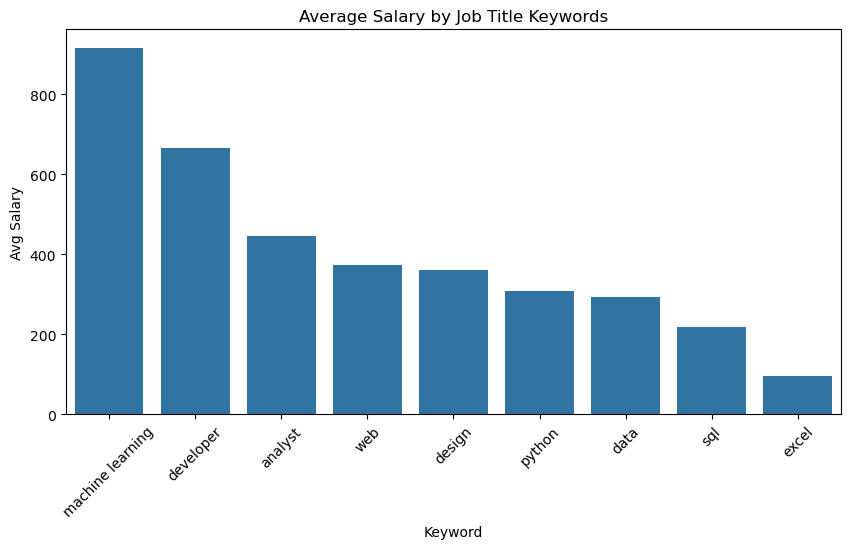

In [7]:
plt.figure(figsize=(10,5))
sns.barplot(data=keyword_salary_df, x='Keyword', y='Avg Salary')
plt.xticks(rotation=45)
plt.title("Average Salary by Job Title Keywords")
plt.show()

In [8]:
#We analyzed job titles by extracting common keywords such as Python, SQL, Data, and Developer.
#The analysis shows that technical roles like Python and Machine Learning tend to offer higher average salaries compared to general roles.

In [9]:
keyword_count = {}

for word in keywords:
    keyword_count[word] = df[df[word] == 1].shape[0]

keyword_count_df = pd.DataFrame(list(keyword_count.items()), columns=['Keyword', 'Job Count'])

keyword_count_df = keyword_count_df.sort_values(by='Job Count', ascending=False)

keyword_count_df

,Keyword,Job Count
7,design,23028
6,web,21022
3,developer,13778
1,data,6593
4,excel,1835
0,python,1816
2,analyst,990
5,sql,587
8,machine learning,256


In [10]:
final_df = pd.merge(keyword_salary_df, keyword_count_df, on='Keyword')

final_df

,Keyword,Avg Salary,Job Count
0,machine learning,916.576172,256
1,developer,666.370446,13778
2,analyst,446.996465,990
3,web,372.508634,21022
4,design,360.446956,23028
5,python,307.496421,1816
6,data,294.298347,6593
7,sql,217.330494,587
8,excel,95.032425,1835


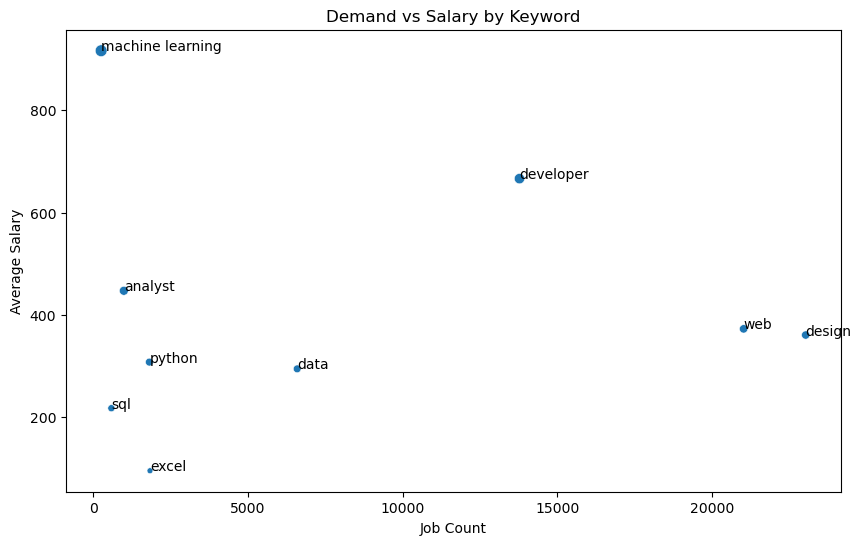

In [11]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=final_df, x='Job Count', y='Avg Salary', size='Avg Salary', legend=False)

for i in range(len(final_df)):
    plt.text(final_df['Job Count'][i], final_df['Avg Salary'][i], final_df['Keyword'][i])

plt.title("Demand vs Salary by Keyword")
plt.xlabel("Job Count")
plt.ylabel("Average Salary")
plt.show()

In [12]:
#We analyzed both salary and demand of job keywords.
#Some roles are high-paying but low demand, while others are high demand but moderate pay.

Emerging Job Categories (Trend Over Time)

In [14]:
df['published_date'] = df['published_date'].dt.tz_localize(None)
df['month'] = df['published_date'].dt.to_period('M')

In [15]:
top_titles = df['title'].value_counts().head(10).index

df_top = df[df['title'].isin(top_titles)]

In [16]:
trend = df_top.groupby(['month', 'title']).size().reset_index(name='count')

trend['month'] = trend['month'].astype(str)

trend.head()

,month,title,count
0,2024-02,Full Stack Developer,49
1,2024-02,Graphic Designer,102
2,2024-02,Lead Generation,31
3,2024-02,Logo Design,99
4,2024-02,Logo Designer,46


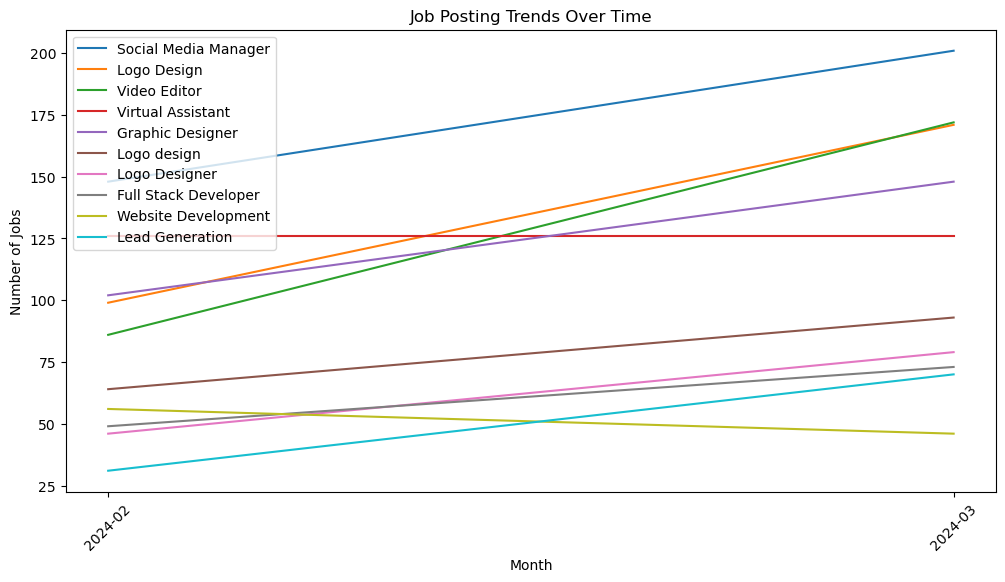

In [17]:
plt.figure(figsize=(12,6))

for title in top_titles:
    temp = trend[trend['title'] == title]
    plt.plot(temp['month'], temp['count'], label=title)

plt.legend()
plt.xticks(rotation=45)
plt.title("Job Posting Trends Over Time")
plt.xlabel("Month")
plt.ylabel("Number of Jobs")
plt.show()

In [18]:
## Roles showing consistent growth are considered emerging job categories.

In [19]:
# total growth per title
growth = trend.groupby('title')['count'].sum().reset_index()

growth = growth.sort_values(by='count', ascending=False)

growth

,title,count
6,Social Media Manager,349
3,Logo Design,270
7,Video Editor,258
8,Virtual Assistant,252
1,Graphic Designer,250
5,Logo design,157
4,Logo Designer,125
0,Full Stack Developer,122
9,Website Development,102
2,Lead Generation,101


Predict High-Demand Job Roles

In [20]:
demand = df['title'].value_counts().reset_index()
demand.columns = ['title', 'total_count']

demand.head()

,title,total_count
0,Social Media Manager,349
1,Logo Design,270
2,Video Editor,258
3,Virtual Assistant,252
4,Graphic Designer,250


In [21]:
trend

,month,title,count
0,2024-02,Full Stack Developer,49
1,2024-02,Graphic Designer,102
2,2024-02,Lead Generation,31
3,2024-02,Logo Design,99
4,2024-02,Logo Designer,46
5,2024-02,Logo design,64
6,2024-02,Social Media Manager,148
7,2024-02,Video Editor,86
8,2024-02,Virtual Assistant,126
9,2024-02,Website Development,56


In [22]:
growth_trend = trend.groupby('title')['count'].mean().reset_index()
growth_trend.columns = ['title', 'avg_monthly_count']

growth_trend.head()

,title,avg_monthly_count
0,Full Stack Developer,61.0
1,Graphic Designer,125.0
2,Lead Generation,50.5
3,Logo Design,135.0
4,Logo Designer,62.5


In [23]:
prediction_df = pd.merge(demand, growth_trend, on='title')

prediction_df = prediction_df.sort_values(by='total_count', ascending=False)

prediction_df.head(10)

,title,total_count,avg_monthly_count
0,Social Media Manager,349,174.5
1,Logo Design,270,135.0
2,Video Editor,258,129.0
3,Virtual Assistant,252,126.0
4,Graphic Designer,250,125.0
5,Logo design,157,78.5
6,Logo Designer,125,62.5
7,Full Stack Developer,122,61.0
8,Website Development,102,51.0
9,Lead Generation,101,50.5


In [24]:
top_roles = prediction_df.head(10)

top_roles

,title,total_count,avg_monthly_count
0,Social Media Manager,349,174.5
1,Logo Design,270,135.0
2,Video Editor,258,129.0
3,Virtual Assistant,252,126.0
4,Graphic Designer,250,125.0
5,Logo design,157,78.5
6,Logo Designer,125,62.5
7,Full Stack Developer,122,61.0
8,Website Development,102,51.0
9,Lead Generation,101,50.5


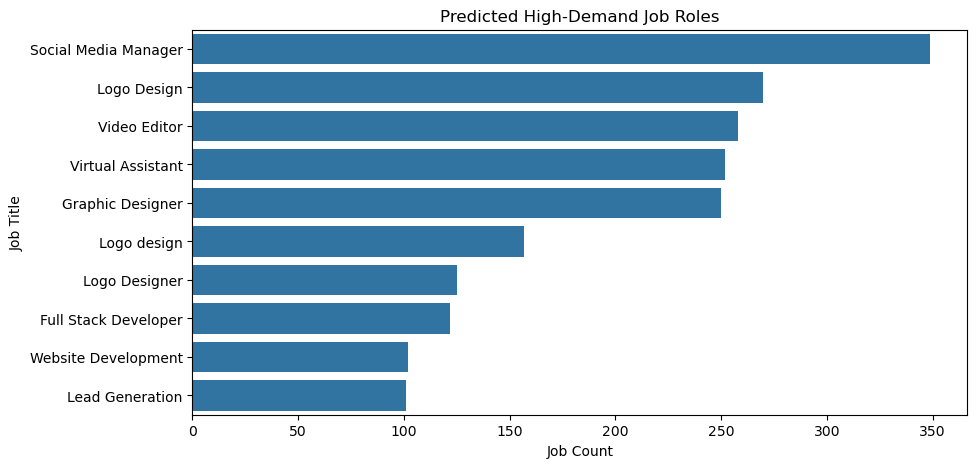

In [25]:
plt.figure(figsize=(10,5))
sns.barplot(data=top_roles, x='total_count', y='title')
plt.title("Predicted High-Demand Job Roles")
plt.xlabel("Job Count")
plt.ylabel("Job Title")
plt.show()

Compare Average Hourly Rates Across Countries

In [26]:
country_salary = df.groupby('country')['salary'].mean().reset_index()

country_salary = country_salary.sort_values(by='salary', ascending=False)

country_salary.head(10)

,country,salary
143,Palau,8900.000000
17,Barbados,2436.523810
179,Sweden,2300.815217
0,Aland Islands,2000.000000
149,Philippines,1985.239444
42,Colombia,1924.200221
50,Czech Republic,1515.087054
173,South Africa,1435.320690
5,Angola,1253.500000
91,Isle of Man,1121.555556


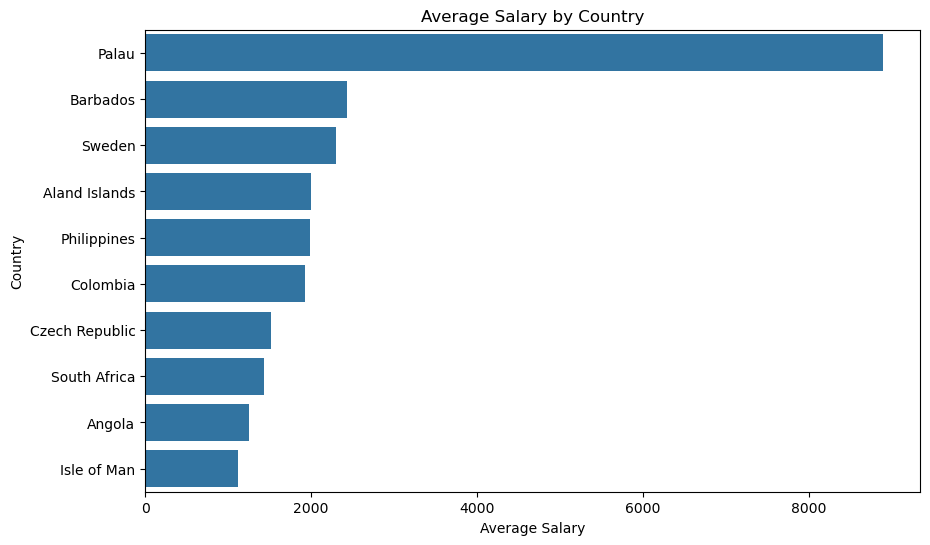

In [27]:
plt.figure(figsize=(10,6))
sns.barplot(data=country_salary.head(10), x='salary', y='country')

plt.title("Average Salary by Country")
plt.xlabel("Average Salary")
plt.ylabel("Country")
plt.show()

In [28]:
df['country'] = df['country'].str.strip()

Job Recommendation System

In [29]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [30]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [31]:
titles = df['title_clean'].dropna().unique()

In [32]:
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(titles)

In [33]:
def recommend_jobs(input_title):
    input_vec = vectorizer.transform([input_title.lower()])
    
    similarity = cosine_similarity(input_vec, tfidf_matrix)
    
    similar_indices = similarity.argsort()[0][-5:][::-1]
    
    return [titles[i] for i in similar_indices]

In [34]:
recommend_jobs("data analyst")

['data analyst',
 'marketing data analyst',
 'business data analyst',
 'data business analyst',
 'youtube data analyst']

In [35]:
print("Input: Data Analyst")
print(recommend_jobs("data analyst"))

print("\nInput: Python Developer")
print(recommend_jobs("python developer"))

Input: Data Analyst
['data analyst', 'marketing data analyst', 'business data analyst', 'data business analyst', 'youtube data analyst']

Input: Python Developer
['python developer', 'python and r developer', 'python developer needed', 'expert python developer', 'python']


In [36]:
titles = list(set(df['title_clean'].dropna()))

In [37]:
def recommend_jobs(input_title):
    input_vec = vectorizer.transform([input_title.lower()])
    
    similarity = cosine_similarity(input_vec, tfidf_matrix)[0]
    
    similar_indices = similarity.argsort()[-6:][::-1]
    
    results = [titles[i] for i in similar_indices if similarity[i] > 0.1]
    
    return results[:5]

Track Changes in Job Market (Monthly Dashboard)

In [38]:
monthly_jobs = df.groupby('month').size().reset_index(name='job_count')

monthly_jobs['month'] = monthly_jobs['month'].astype(str)

monthly_jobs

,month,job_count
0,2023-11,1
1,2023-12,6
2,2024-01,77
3,2024-02,84628
4,2024-03,117954


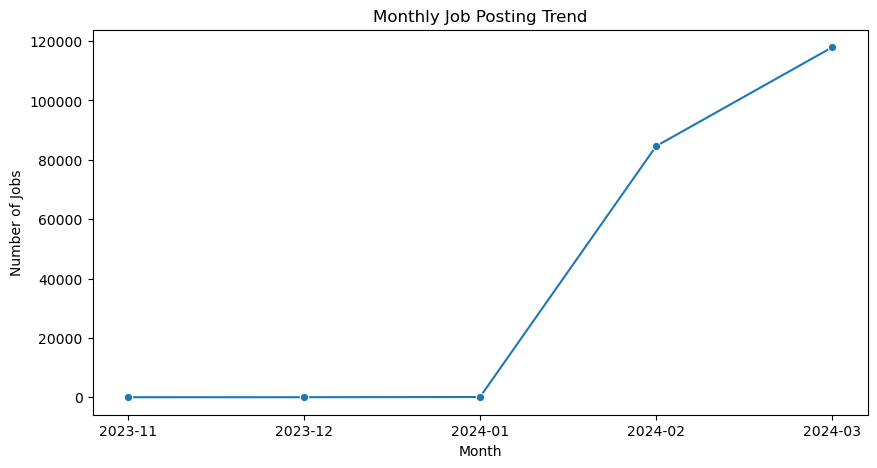

In [39]:
plt.figure(figsize=(10,5))
sns.lineplot(data=monthly_jobs, x='month', y='job_count', marker='o')

plt.title("Monthly Job Posting Trend")
plt.xlabel("Month")
plt.ylabel("Number of Jobs")
plt.show()

In [40]:
monthly_jobs['change'] = monthly_jobs['job_count'].diff()

monthly_jobs

,month,job_count,change
0,2023-11,1,NaN
1,2023-12,6,5.0
2,2024-01,77,71.0
3,2024-02,84628,84551.0
4,2024-03,117954,33326.0


Remote Work Trends

In [41]:
job_type = df['is_hourly'].value_counts().reset_index()
job_type.columns = ['Type', 'Count']

job_type

,Type,Count
0,False,103891
1,True,98775


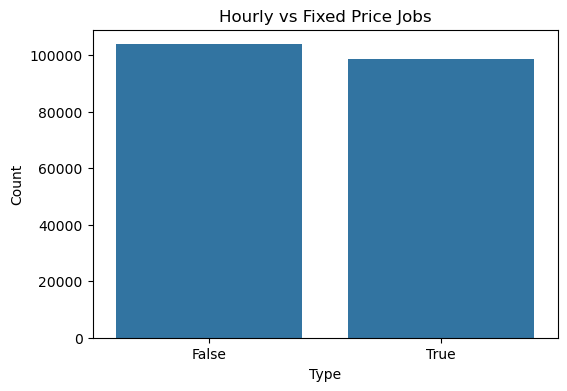

In [42]:
plt.figure(figsize=(6,4))
sns.barplot(data=job_type, x='Type', y='Count')

plt.title("Hourly vs Fixed Price Jobs")
plt.show()

In [43]:
salary_by_type = df.groupby('is_hourly')['salary'].mean().reset_index()

salary_by_type

,is_hourly,salary
0,False,911.473564
1,True,29.709263


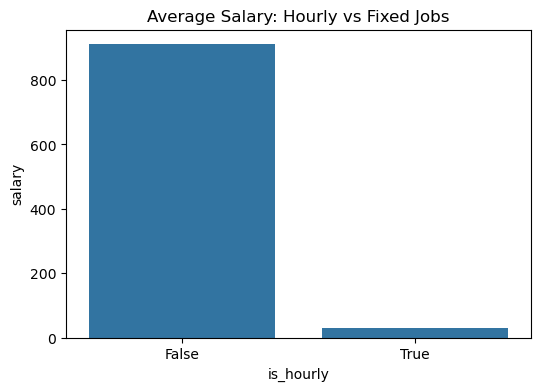

In [44]:
plt.figure(figsize=(6,4))
sns.barplot(data=salary_by_type, x='is_hourly', y='salary')

plt.title("Average Salary: Hourly vs Fixed Jobs")
plt.show()

Future Job Market Trends

In [45]:
monthly_jobs

,month,job_count,change
0,2023-11,1,NaN
1,2023-12,6,5.0
2,2024-01,77,71.0
3,2024-02,84628,84551.0
4,2024-03,117954,33326.0


In [46]:
monthly_jobs['trend'] = monthly_jobs['job_count'].rolling(2).mean()

monthly_jobs

,month,job_count,change,trend
0,2023-11,1,NaN,NaN
1,2023-12,6,5.0,3.5
2,2024-01,77,71.0,41.5
3,2024-02,84628,84551.0,42352.5
4,2024-03,117954,33326.0,101291.0


In [47]:
# simple next value prediction
last_value = monthly_jobs['job_count'].iloc[-1]
avg_change = monthly_jobs['job_count'].diff().mean()

future_prediction = last_value + avg_change

print("Predicted next month's job count:", future_prediction)

Predicted next month's job count: 147442.25


In [48]:
top_roles[['title', 'total_count']].head(5)

,title,total_count
0,Social Media Manager,349
1,Logo Design,270
2,Video Editor,258
3,Virtual Assistant,252
4,Graphic Designer,250


In [49]:
# Example outputs
recommend_jobs("data analyst")
recommend_jobs("python developer")

['import sales: textile',
 'seeking affiliates for strategic partnership in seo services',
 'calling the attention of dietician and nutrutionist',
 'sjc fresh juice demonstration specialist march 28th only',
 'video editor for youtube channel about scary stories']

## Conclusion

This project analyzed job market trends using real-world job posting data. Key insights include the identification of high-demand roles, salary variations across job types and countries, and emerging job categories.

A recommendation system was successfully developed using text similarity techniques to suggest relevant job roles. Additionally, short-term predictions were made to estimate future job market trends.

Overall, this project demonstrates how data analysis and simple machine learning techniques can be used to extract meaningful insights and support decision-making in the job market.